In [ ]:
!pip install pandas torch torchvision pillow matplotlib tqdm

In [ ]:
import os
from pathlib import Path
from google.colab import drive

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Constants
DATA_DIR = "/content/drive/MyDrive/ML_Safety"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "validation")
BATCH_SIZE = 32
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class CarlaDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.img_dir = os.path.join(data_dir, "rgb-front")

        # Load labels
        labels_file = os.path.join(data_dir, "labels.csv")
        self.df = pd.read_csv(labels_file)

        # Format the frame strings to match image filenames
        img_names = os.listdir(self.img_dir)
        self.ext = ".jpg"
        if len(img_names) > 0 and img_names[0].endswith(".png"):
            self.ext = ".png"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = str(row['frame']).zfill(6)
        img_path = os.path.join(self.img_dir, frame + self.ext)

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        labels = {
            'traffic_light': torch.tensor(row['has_traffic_light'], dtype=torch.float32),
            'pedestrian': torch.tensor(row['has_pedestrian'], dtype=torch.float32),
            'vehicle': torch.tensor(row['has_vehicle'], dtype=torch.float32)
        }
        return image, labels

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CarlaDataset(TRAIN_DIR, transform=transform)
val_dataset = CarlaDataset(VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
import os

print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("VAL_DIR exists:", os.path.exists(VAL_DIR))

DATA_DIR exists: True
TRAIN_DIR exists: True
VAL_DIR exists: True


In [ ]:
def create_model():
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 1) # Binary classification logit
    return model.to(DEVICE)

def train_model(target_class, epochs=EPOCHS):
    print(f"\n--- Training {target_class} Model ---")
    model = create_model()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs = inputs.to(DEVICE)
            targets = labels[target_class].to(DEVICE).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                inputs = inputs.to(DEVICE)
                targets = labels[target_class].to(DEVICE).unsqueeze(1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1}: Train Loss = {epoch_train_loss:.4f}, Val Loss = {epoch_val_loss:.4f}")

    return model, train_losses, val_losses

In [ ]:
# Train models for each task
models_dict = {}
history_dict = {}
targets = ['pedestrian', 'traffic_light', 'vehicle']

for target in targets:
    model, train_loss, val_loss = train_model(target, epochs=5)
    models_dict[target] = model
    history_dict[target] = {'train': train_loss, 'val': val_loss}


--- Training pedestrian Model ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]
Epoch 1/5 [Train]:   0%|          | 0/225 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create.

Epoch 1: Train Loss = 0.4446, Val Loss = 0.7238


Epoch 2/5 [Val]: 100%|██████████| 113/113 [00:24<00:00,  4.58it/s]


Epoch 2: Train Loss = 0.2933, Val Loss = 0.6244


...

Epoch 3: Train Loss = 0.1264, Val Loss = 0.3021


Epoch 4/5 [Val]: 100%|██████████| 113/113 [00:26<00:00,  4.35it/s]


Epoch 4: Train Loss = 0.0950, Val Loss = 0.3280


Epoch 5/5 [Val]: 100%|██████████| 113/113 [00:25<00:00,  4.51it/s]

Epoch 5: Train Loss = 0.0784, Val Loss = 0.3240


In [ ]:
targets

['pedestrian', 'traffic_light', 'vehicle']

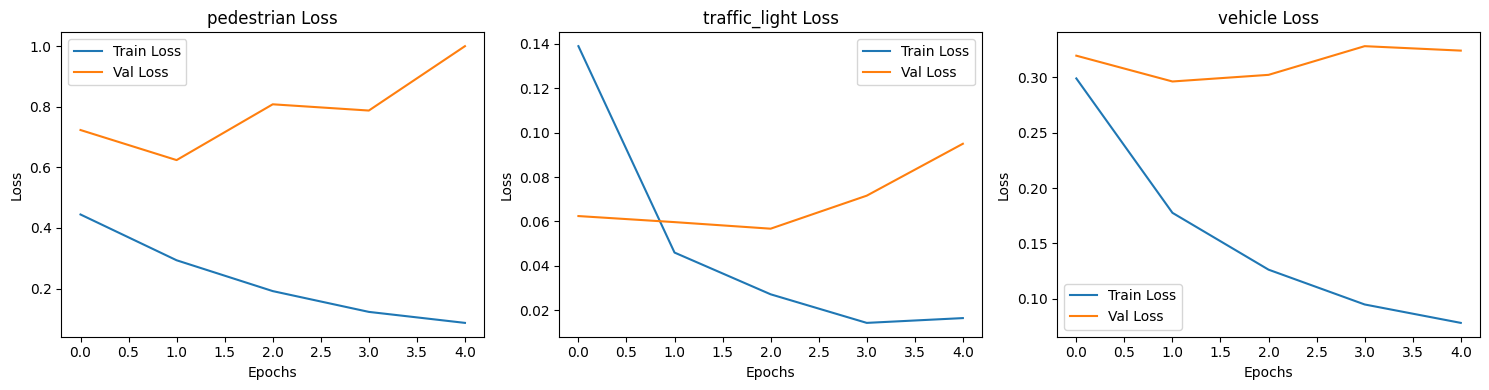

In [ ]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, target in enumerate(targets):
    ax = axes[i]
    ax.plot(history_dict[target]['train'], label='Train Loss')
    ax.plot(history_dict[target]['val'], label='Val Loss')
    ax.set_title(f'{target} Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/ML_Safety/models"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in models_dict.items():
    path = os.path.join(SAVE_DIR, f"{name}_resnet18.pth")
    torch.save(model.state_dict(), path)
    print(f"Saved {name} model to {path}")

Saved pedestrian model to /content/drive/MyDrive/ML_Safety/models/pedestrian_resnet18.pth
Saved traffic_light model to /content/drive/MyDrive/ML_Safety/models/traffic_light_resnet18.pth
Saved vehicle model to /content/drive/MyDrive/ML_Safety/models/vehicle_resnet18.pth


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Make sure TEST_DIR is pointing to your test split folder
TEST_DIR = os.path.join(DATA_DIR, "test")
test_dataset = CarlaDataset(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

def evaluate_model(model, target_class):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Evaluating {target_class}"):
            inputs = inputs.to(DEVICE)
            targets = labels[target_class].numpy()

            outputs = model(inputs)
            # Apply sigmoid and threshold at 0.5 for binary prediction
            preds = torch.sigmoid(outputs).cpu().numpy() >= 0.5

            all_preds.extend(preds.flatten())
            all_targets.extend(targets)

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    return acc, prec, rec, f1

results = {}
for target in targets:
    acc, prec, rec, f1 = evaluate_model(models_dict[target], target)
    results[target] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

# Print results nicely
results_df = pd.DataFrame(results).T
print("\nTest Evaluation Results:")
display(results_df)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating pedestrian:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_n


Test Evaluation Results:


,Accuracy,Precision,Recall,F1
pedestrian,0.778889,0.421875,0.344193,0.379095
traffic_light,0.939167,0.938776,0.979102,0.958515
vehicle,0.888611,0.975196,0.873704,0.921664


In [ ]:
print("hi")

hi


In [ ]:
results_df

,Accuracy,Precision,Recall,F1
pedestrian,0.778889,0.421875,0.344193,0.379095
traffic_light,0.939167,0.938776,0.979102,0.958515
vehicle,0.888611,0.975196,0.873704,0.921664


Evaluating pedestrian:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating traffic_light:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to av

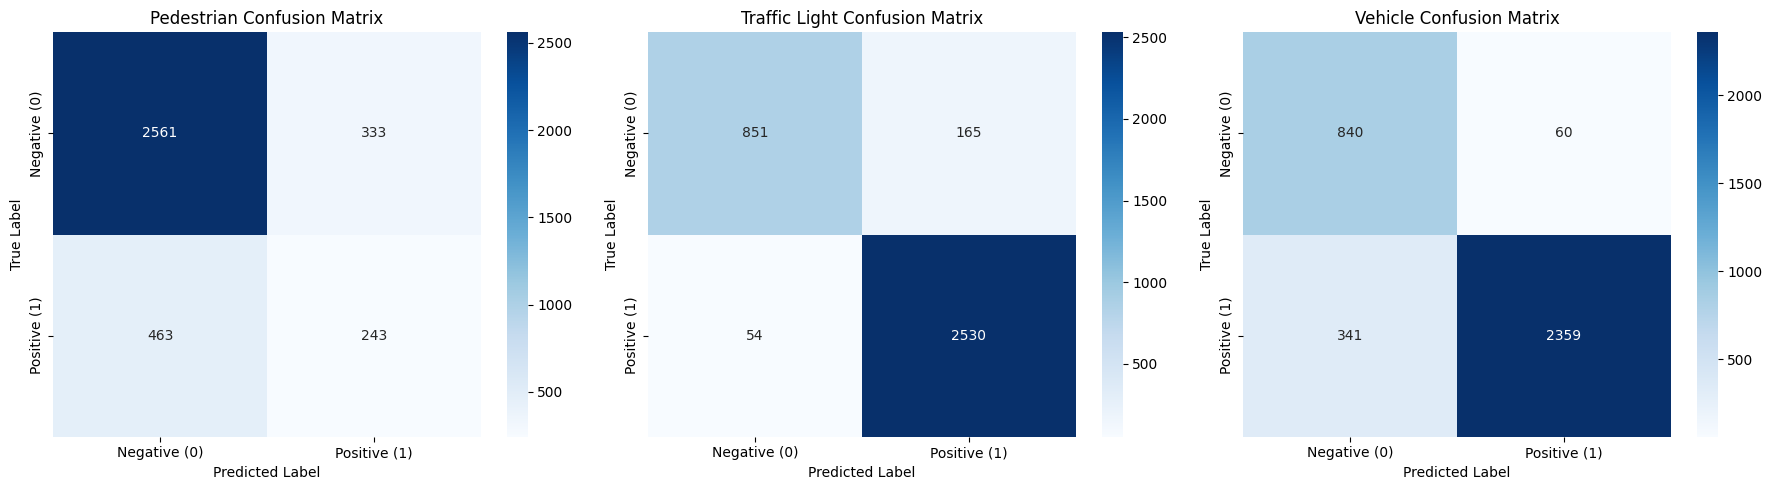

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_and_plot_cm(model, target_class):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Evaluating {target_class}"):
            inputs = inputs.to(DEVICE)
            targets = labels[target_class].numpy()

            outputs = model(inputs)
            preds = torch.sigmoid(outputs).cpu().numpy() >= 0.5

            all_preds.extend(preds.flatten())
            all_targets.extend(targets)

    # Calculate confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    return cm

# Plotting the confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(targets):
    cm = evaluate_and_plot_cm(models_dict[target], target)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'])
    axes[i].set_title(f'{target.replace("_", " ").title()} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [ ]:
print("hi")

hi
